In [69]:
!pip install cpmpy numpy gurobipy pychoco networkx colorama --quiet
import cpmpy as cp
import numpy as np
import pandas as pd

## **Session 5 : Encodings**

Welcome to the fifth exercise session of Declarative Problem Solving Paradigms in AI. In this session, we'll have a deeper look at the component of a model+solve system that we've somewhat been ignoring untill now; **the solver**.

Modeling-systems like CPMpy allow you to work in a high-level Constraint Programming language whilst being able to interchange the target solving backend in a transparant manner. There is no need (from a purely functional point of view) to be aware of how this backend functions, what lower-level language it accepts, for what types of problems it was originally designed, etc. The solver acts as a black box.

But now a counter-argument to this idealistic model+solve vision:
As a good modeler, and also from the lectures, you should understand that having some knowledge of the internal workings will allow you to make better "model-solver" combinations. How you formulate a model (e.g. integer vs boolean decision variables, global constraints, etc) will have an impact on the solver's performance depending on its particular technology. And choosing the right solver for the problem at hand (e.g. a technology that is very good at solving scheduling problems) can result in significant speed improvements.

As seen in the lectures, a high-level modeling language the likes of CPMpy will support many solving backends (OR-Tools, Choco, Exact, Gurobi, ...) which are based on various solving technologies (CP, SAT, Pseudo-Boolean, ILP, ...). CPMpy utilises a "waterfall"-like transformation architecture as to stepwise translate a high-level model into the lower-level input language of one such technology.

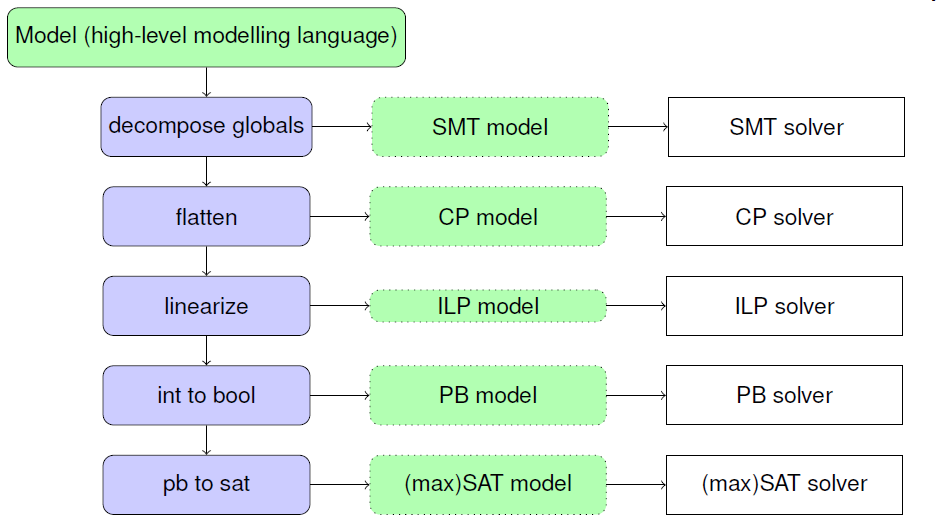

**Useful Resources:**
* CPMpy summary sheet: https://cpmpy.readthedocs.io/en/latest/summary.html
* CPMpy modeling documentation: https://cpmpy.readthedocs.io/en/latest/modeling.html
* CPMpy full documentation: https://cpmpy.readthedocs.io/en/latest/index.html
* List of supported solvers / solving technologies: https://cpmpy.readthedocs.io/en/latest/#supported-solvers

### 5.1 Decomposition of unsupported globals

A chosen decomposition will result in a large collection of "conceptually simpler" constraints, but when not adapting to the technology and especially its input language, this could still result in a more difficult model to solve then when using a different decomposition.

#### **0. Setup**

In [70]:
"""
Load helper function to check model solution.
"""
from colorama import Fore, Style
def check_unique_elements(lst):
    """
    Checks if all elements in a list are unique.
    """
    unique_elements = set(lst)
    if len(unique_elements) != len(lst):
        print("Not all elements are unique. The following elements are not unique:")
    for element in lst:
        if list(lst).count(element) > 1:
            print(Fore.RED + str(element) + Style.RESET_ALL, end=' ')
        else:
            print(Fore.GREEN + str(element) + Style.RESET_ALL, end=' ')
    print()

#### **1: AllDifferent: from global constraint to generic decomposition**

Examine the following model using the `AllDifferent` global constraint.

In [71]:
import cpmpy as cp
from cpmpy import SolverLookup

"""
A simple model using the `AllDifferent` global constraint.
"""

# Decision Variables
x = cp.intvar(0, 10, shape=10,name='x')

# Model
model = cp.Model()

# Constraints
# 1) all x'es should be different
model.add(cp.AllDifferent(x))

# Solve
solver = SolverLookup().get("gurobi", model)
solver.solve()

# Show result
check_unique_elements(x.value())
print(solver.status())

2 4 1 9 7 5 3 6 0 10 
ExitStatus.FEASIBLE (0.00011801719665527344 seconds)


Write a new model where you replace the `AllDifferent` constraint with a collection of decomposed pairwise `!=` constraints (lecture 06 slide 17).

In [72]:
import itertools
from cpmpy import SolverLookup

# Decision Variables
x = cp.intvar(0, 10, shape=10,name='x')

# Model
model = cp.Model()

# Constraints
# 1) All elements of 'x' should be unique.
"""
TODO: Write down the != decomposition for `AllDifferent`

HINT: Use itertools.combinations(x, 2) to generate all pairwise combinations of elements of x.
"""
# ┌────TO DO────┐
for (a,b) in itertools.combinations(x, 2):
    model.add(a != b)
# └─────────────┘

# Solve
solver = SolverLookup().get("gurobi", model)
solver.solve()

# Show result
check_unique_elements(x.value())
print(solver.status())

8 2 4 3 10 6 5 1 0 7 
ExitStatus.FEASIBLE (0.0024759769439697266 seconds)


**Q**: Compare the solve time against that of the above model. Why the difference in solve time? Why is the decomposition using "!=" not suitable for the chosen solver "Gurobi", an ILP solver.

**Solution:**

As expected, the decomposed model is slower to solve. Not only due to no longer using a global constraint (which benefits from stronger reasoning), but also due to the use of `!=` constraints in combination with a ILP solver; Gurobi. ILP solvers require a linearization transformation on each expression before it can get posted to the solver. As seen in the lectures, for `!=` this will result in two big-M constraints, which is not ideal for performance-reasons.

In [73]:
# Decision Variables
x = cp.intvar(0, 10, shape=10,name='x')

# Model
model_1 = cp.Model()
model_1.add(cp.AllDifferent(x))

model_2 = cp.Model()
# ┌────PREVIOUS MODEL HERE────┐
for (a,b) in itertools.combinations(x, 2):
    model_2.add(a != b)
# └───────────────────────────┘

# show the transformations
solver = SolverLookup().get("gurobi")
constraints_model_1 = solver.transform(model_1.constraints)
constraints_model_2 = solver.transform(model_2.constraints)
print(f'All different results in {len(constraints_model_1)} constraints after transformation')
print(f'Your model results in {len(constraints_model_2)} constraints after transformation')

print('------Constraints: AllDifferent Model------')
print(constraints_model_1)
print('------Constraints: Your Model------')
print(constraints_model_2)


All different results in 31 constraints after transformation
Your model results in 90 constraints after transformation
------Constraints: AllDifferent Model------
[sum([BV2824, BV2825, BV2826, BV2827, BV2828, BV2829, BV2830, BV2831, BV2832, BV2833, BV2834]) == 1, sum([BV2835, BV2836, BV2837, BV2838, BV2839, BV2840, BV2841, BV2842, BV2843, BV2844, BV2845]) == 1, sum([BV2846, BV2847, BV2848, BV2849, BV2850, BV2851, BV2852, BV2853, BV2854, BV2855, BV2856]) == 1, sum([BV2857, BV2858, BV2859, BV2860, BV2861, BV2862, BV2863, BV2864, BV2865, BV2866, BV2867]) == 1, sum([BV2868, BV2869, BV2870, BV2871, BV2872, BV2873, BV2874, BV2875, BV2876, BV2877, BV2878]) == 1, sum([BV2879, BV2880, BV2881, BV2882, BV2883, BV2884, BV2885, BV2886, BV2887, BV2888, BV2889]) == 1, sum([BV2890, BV2891, BV2892, BV2893, BV2894, BV2895, BV2896, BV2897, BV2898, BV2899, BV2900]) == 1, sum([BV2901, BV2902, BV2903, BV2904, BV2905, BV2906, BV2907, BV2908, BV2909, BV2910, BV2911]) == 1, sum([BV2912, BV2913, BV2914, BV2915,

#### **2: Nvalue: from global constraint to generic decomposition**

Five tasks need to be assigned to one of four available machines, numbered 0 through 3. A CPMpy model ensures that each task is assigned to a machine, and that exactly three distinct machines are used in total. The model ensures this by using a `NValue` global constraint.

In [74]:
num_tasks = 5
num_machines = 4
machines = cp.intvar(0, num_machines-1, shape=num_tasks, name='machines')
model = cp.Model()

# NValue constraint: exactly 3 different machines used
model.add((cp.NValue(machines) == 3))

# ┌────Change with whichever solver you want────┐
solver = 'choco'
s = cp.SolverLookup.get(solver)
print(f'Transformation for NValue when using {solver}: {s.transform(model.constraints)}\n')
# └────────────────────────────────────────────┘

# ┌────Change with whichever solver you want────┐
solver = 'gurobi'
s = cp.SolverLookup.get(solver)
print(f'Transformation for NValue when using {solver}: {s.transform(model.constraints)}')
# └────────────────────────────────────────────┘

Transformation for NValue when using choco: [nvalue(machines[0],machines[1],machines[2],machines[3],machines[4]) == 3]

Transformation for NValue when using gurobi: [sum([BV2979, BV2980, BV2981, BV2982]) == 3, (BV2979) -> (sum([BV2983, BV2984, BV2985, BV2986, BV2987]) >= 1), sum([-1, 1] * [BV2979, BV2983]) <= 0, sum([-1, 1] * [BV2979, BV2984]) <= 0, sum([-1, 1] * [BV2979, BV2985]) <= 0, sum([-1, 1] * [BV2979, BV2986]) <= 0, sum([-1, 1] * [BV2979, BV2987]) <= 0, (BV2983) -> (sum([machines[0]]) == 0), (~BV2983) -> (sum([1, -4] * [machines[0], BV3003]) <= -1), (~BV2983) -> (sum([1, -1] * [machines[0], BV3003]) >= 0), sum([1, 1] * [BV2983, BV3003]) <= 1, (BV2984) -> (sum([machines[1]]) == 0), (~BV2984) -> (sum([1, -4] * [machines[1], BV3004]) <= -1), (~BV2984) -> (sum([1, -1] * [machines[1], BV3004]) >= 0), sum([1, 1] * [BV2984, BV3004]) <= 1, (BV2985) -> (sum([machines[2]]) == 0), (~BV2985) -> (sum([1, -4] * [machines[2], BV3005]) <= -1), (~BV2985) -> (sum([1, -1] * [machines[2], BV3005])

Rewrite the `NValue` constraint by using a 'value' expression and a set of defining constraints (lecture 06 slide 17).

In [75]:
# Number of tasks and machines
num_tasks = 5
num_machines = 4
machines = cp.intvar(0, num_machines-1, shape=num_tasks, name='machines')
model = cp.Model()
# B[m] = 1 iff machine m is used
B = cp.boolvar(shape=num_machines, name="B")

# ┌────SOLUTION────┐
# 1) Sum of B[m] = 3   (exactly 3 distinct machines)    #value expression
model.add((sum(B) == 3))
# 2) for value v:  B[m] = OR (t == m for t in tasks)    #defining constraint
for m in range(num_machines):
    model.add((B[m] == cp.any(machines[i] == m for i in range(num_tasks))))
# └────────────────┘

# Solve
if model.solve():
    print(model.status())
    print("Number of distinct machines used:", len(set(machines.value())))
else:
    print("No solution found.")

ExitStatus.FEASIBLE (0.004860752 seconds)
Number of distinct machines used: 3


#### **3: Negating decomposed global constraints**

Following the previous problem, we now aim to ensure that four machines are not used. We do that by negativing the `NValue` global constraint.

In [76]:
num_tasks = 5
num_machines = 4
machines = cp.intvar(0, num_machines-1, shape=num_tasks, name='machines')
model = cp.Model()

# NValue constraint: exactly 4 different machines must not be used
model.add(~(cp.NValue(machines) == 4))

#IGNORE THIS: artificial constraint to limit the number of solutions
model.add(cp.sum(machines) == 3)

# Solve
sols_ground_truth = model.solveAll(display=machines)
print(f'{sols_ground_truth} distinct solutions found')

[0 0 0 0 3]
[3 0 0 0 0]
[0 3 0 0 0]
[0 0 3 0 0]
[0 0 0 3 0]
[1 1 1 0 0]
[0 1 1 1 0]
[1 0 1 1 0]
[1 1 0 1 0]
[0 1 0 1 1]
[1 0 0 1 1]
[0 0 1 1 1]
[1 0 1 0 1]
[0 1 1 0 1]
[1 1 0 0 1]
[2 0 0 0 1]
[2 1 0 0 0]
[2 0 1 0 0]
[2 0 0 1 0]
[1 2 0 0 0]
[1 0 2 0 0]
[1 0 0 2 0]
[1 0 0 0 2]
[0 0 1 0 2]
[0 0 0 1 2]
[0 0 2 1 0]
[0 0 2 0 1]
[0 0 0 2 1]
[0 0 1 2 0]
[0 2 1 0 0]
[0 1 2 0 0]
[0 2 0 0 1]
[0 1 0 0 2]
[0 1 0 2 0]
[0 2 0 1 0]
35 distinct solutions found


How do we decompose this global constraint?

In [77]:
# Number of tasks and machines
num_tasks = 5
num_machines = 4
machines = cp.intvar(0, num_machines-1, shape=num_tasks, name='machines')
model = cp.Model()
# B[v] = 1 iff value v appears in machines
B = cp.boolvar(shape=4, name="B")

# ┌────SOLUTION────┐
# 1) Sum of B[m] = 4   (exactly 4 distinct machines)    #value expression
model.add(~(sum(B) == 4))
# 2) for value v:  B[m] = OR (t == m for t in tasks)    #defining constraint
for m in range(num_machines):
    model.add((B[m] == cp.any(machines[i] == m for i in range(num_tasks))))
# └────────────────┘

#IGNORE THIS: artificial constraint to limit the number of solutions
model.add(cp.sum(machines) == 3)

# Solve
sols_found = model.solveAll(display=[machines,B])
print(f'{sols_found} solutions found')
if sols_ground_truth<sols_found:
    print(f'Something went wrong, your model gives more solutions then expected : {sols_found} > {sols_ground_truth}')
elif sols_ground_truth>sols_found:
    print(f'Something went wrong, your model gives less solutions then expected : {sols_found} < {sols_ground_truth}')
elif sols_ground_truth==sols_found:
    print(f'Your negation is correct!')

[[0, 0, 0, 0, 3], [True, False, False, True]]
[[3, 0, 0, 0, 0], [True, False, False, True]]
[[0, 3, 0, 0, 0], [True, False, False, True]]
[[0, 0, 3, 0, 0], [True, False, False, True]]
[[0, 0, 0, 3, 0], [True, False, False, True]]
[[1, 1, 1, 0, 0], [True, True, False, False]]
[[0, 1, 1, 1, 0], [True, True, False, False]]
[[1, 0, 1, 1, 0], [True, True, False, False]]
[[1, 1, 0, 1, 0], [True, True, False, False]]
[[0, 1, 0, 1, 1], [True, True, False, False]]
[[1, 0, 0, 1, 1], [True, True, False, False]]
[[0, 0, 1, 1, 1], [True, True, False, False]]
[[1, 0, 1, 0, 1], [True, True, False, False]]
[[0, 1, 1, 0, 1], [True, True, False, False]]
[[1, 1, 0, 0, 1], [True, True, False, False]]
[[2, 0, 0, 0, 1], [True, True, True, False]]
[[2, 1, 0, 0, 0], [True, True, True, False]]
[[2, 0, 1, 0, 0], [True, True, True, False]]
[[2, 0, 0, 1, 0], [True, True, True, False]]
[[1, 2, 0, 0, 0], [True, True, True, False]]
[[1, 0, 2, 0, 0], [True, True, True, False]]
[[1, 0, 0, 2, 0], [True, True, True, Fal

### 5.2 From CP Language to CP solver: Flattening

We will now focus on the steps required for translating CP language to primitive constraints that the CP solver can accept, specifically on flattening, which replaces sub-expressions with auxiliary variables.

#### **0. Setup**

In [78]:
import itertools

# ---------------------------------------------------
# 1. Ground truth
# ---------------------------------------------------
def ground_truth(domain, op):
    rows = []
    for x, y, z, u, v in itertools.product(domain, repeat=5):
        b1 = int(y <= z)
        b2 = int(u > v)
        lhs = 2*x + b1 + b2   # left-hand side

        if op == "=":
            sat = int(lhs == 5)
        elif op == "<":
            sat = int(lhs < 5)
        elif op == ">":
            sat = int(lhs > 5)
        else:
            raise ValueError("type must be '=', '<', '>'")

        rows.append({
            "x": x, "y": y, "z": z, "u": u, "v": v,
            "2*x + (y <= z) + (u > v)": lhs, "ground_truth": sat
        })
    return pd.DataFrame(rows)

# ---------------------------------------------------
# 2. Student model evaluation
# ---------------------------------------------------
def model_truth(model, x, y, z, u, v, domain):
    rows = []
    names = ["x", "y", "z", "u", "v"]

    for values in itertools.product(domain, repeat=5):
        vx, vy, vz, vu, vv = values

        # Fix variables and check satisfiability
        m = cp.Model(model.constraints + [
            x == vx, y == vy, z == vz, u == vu, v == vv
        ])
        sat = int(m.solve())

        row = dict(zip(names, values))
        row["your_model"] = sat
        rows.append(row)

    return pd.DataFrame(rows)


# ---------------------------------------------------
# 3. Compare & show errors as DataFrame
# ---------------------------------------------------
def check_model(model, x, y, z, u, v, type="=",big_m=False):
    domain = range(3)

    df_ground = ground_truth(domain, type)
    df_model  = model_truth(model, x, y, z, u, v, domain)

    # merge
    df = pd.merge(df_ground, df_model, on=["x","y","z","u","v"])

    # mismatches only
    df_bad = df[df["ground_truth"] != df["your_model"]].copy()

    if not big_m:
        if len(model.constraints) != len(cp.transformations.flatten_model.flatten_constraint(model.constraints)):
            print('Your model does not seem to be flat yet')
    else:
        for c in model.constraints:
            if '->' in str(c):
                print("Implications are not expected")

    if df_bad.empty:
        print("Expression matches ground truth")
        return

    print("Incorrect rows — expression does NOT match ground truth:")
    return df_bad



def ground_truth_formula(domain_int):
    rows = []
    for x, y in itertools.product(domain_int, repeat=2):
        for a, b, c, d in itertools.product([0,1], repeat=4):

            a_b = bool(a)
            b_b = bool(b)
            c_b = bool(c)
            d_b = bool(d)

            # P = (x >= 3 - y)
            P = (x >= 3 - y)

            # (b -> c) = (not b) or c
            b_implies_c = (not b_b) or c_b

            # RHS: a or (b and (b -> c)) or d
            right = a_b or (b_b and b_implies_c) or d_b

            # Formula: P -> right = (not P) or right
            formula = (not P) or right

            rows.append({
                "x": x,
                "y": y,
                "a": a,
                "b": b,
                "c": c,
                "d": d,
                "ground_true": int(formula)
            })
    return pd.DataFrame(rows)


def model_truth_formula(expr, x, y, a, b, c, d, domain_int):
    rows = []
    for xv, yv in itertools.product(domain_int, repeat=2):
        for av, bv, cv, dv in itertools.product([0,1], repeat=4):

            m = cp.Model([
                expr,
                x == xv,
                y == yv,
                a == av,
                b == bv,
                c == cv,
                d == dv,
            ])

            sat = int(m.solve())

            rows.append({
                "x": xv,
                "y": yv,
                "a": av,
                "b": bv,
                "c": cv,
                "d": dv,
                "model_true": sat
            })
    return pd.DataFrame(rows)


def check_formula(expr, x, y, a, b, c, d, domain_int=range(3)):
    """
    Check that `expr` is equivalent to:
        (x >= 3 - y) -> (a or (b and (b -> c)) or d)
    Returns a DataFrame with only incorrect rows.
    """
    df_ground = ground_truth_formula(domain_int)
    df_model  = model_truth_formula(expr, x, y, a, b, c, d, domain_int)

    df = pd.merge(df_ground, df_model,
                  on=["x","y","a","b","c","d"])

    df_bad = df[df["ground_true"] != df["model_true"]].copy()

    if df_bad.empty:
        print("Expression matches ground truth")
    else:
        print("Incorrect rows — expression does NOT match ground truth:")
        return df_bad
    if not is_simplified_shape(expr, x, y, a, b, c, d):
        print("Your expression is logically correct but not simplified as required.")
    return None


def is_simplified_shape(expr, x, y, a, b, c, d):
    """
    Return True iff expr has the exact shape:
        (x + y < 3) | a | (b & c) | d
    This function is only for the hidden checker, not shown to students.
    """

    args = expr.args
    if len(args) != 4:
        return False

    # build the 4 target subexpressions (hidden reference)
    t1 = (x + y < 3)
    t2 = a
    t3 = (b & c)
    t4 = d

    targets = [t1, t2, t3, t4]

    # we compare by string, which is simple and good enough here
    arg_strs    = sorted(str(a) for a in args)
    target_strs = sorted(str(t) for t in targets)

    return arg_strs == target_strs



Consider the following constraints:

$2 \cdot x + (y \le z) + (u > v) = 5$

$2 \cdot x + (y \le z) + (u > v) > 5$

$2 \cdot x + (y \le z) + (u > v) < 5$

Your goal is to flatten these expressions following suggestions from Lecture 07 slide 8, simplify using half reification as well (if possible)

In [79]:
#BLOCK FOR  2*x + (y <= z) + (u > v) = 5

# Domains for all integer variables
x = cp.intvar(0,2, name='x')
y = cp.intvar(0,2, name='y')
z = cp.intvar(0,2, name='z')
u = cp.intvar(0,2, name='u')
v = cp.intvar(0,2, name='v')
model = cp.Model()

# ┌────SOLUTION────┐
# 1) Definition of the boolean variables
bv1 =  cp.boolvar()
bv2 =  cp.boolvar()
# 2) definition new expression
model.add(2*x + bv1 + bv2 == 5)
# 3) reification
model.add((bv1 == (y <= z)))
model.add((bv2 == (u > v)))
# └────────────────┘

model.solve()
check_model(model, x, y, z, u, v, type="=")

Expression matches ground truth


In [80]:
#BLOCK FOR  2*x + (y <= z) + (u > v) > 5

# Domains for all integer variables
x = cp.intvar(0,2, name='x')
y = cp.intvar(0,2, name='y')
z = cp.intvar(0,2, name='z')
u = cp.intvar(0,2, name='u')
v = cp.intvar(0,2, name='v')
model = cp.Model()

# ┌────SOLUTION────┐
# 1) Definition of the boolean variables
bv1 =  cp.boolvar()
bv2 =  cp.boolvar()
# 2) definition new expression
model.add(2*x + bv1 + bv2 > 5)
# 3) reification
model.add(((bv1).implies(y <= z)))
model.add(((bv2).implies(u > v)))
# └────────────────┘

model.solve()
check_model(model, x, y, z, u, v, type=">")


Expression matches ground truth


In [81]:
#BLOCK FOR  2*x + (y <= z) + (u > v) < 5

# Domains for all integer variables
x = cp.intvar(0,2, name='x')
y = cp.intvar(0,2, name='y')
z = cp.intvar(0,2, name='z')
u = cp.intvar(0,2, name='u')
v = cp.intvar(0,2, name='v')
model = cp.Model()

# ┌────SOLUTION────┐
# 1) Definition of the boolean variables
bv1 =  cp.boolvar()
bv2 =  cp.boolvar()
# 2) definition new expression
model.add(2*x + bv1 + bv2 < 5)
# 3) reification
model.add((y <= z).implies(bv1))
model.add((u > v).implies(bv2))
# └────────────────┘

model.solve()
check_model(model, x, y, z, u, v, type="<")

Expression matches ground truth


### 5.3 From CP Language to CP solver: Normalization and Simplification

Before flattening, we aim to give the solver a more compact formulation by simplifying and normalizing the expressions. This avoids introducing unnecessary auxiliary variables and involves normalizing linear sums and merging nested n-ary operators (Lecture 07, slide 10).

Consider the following constraints:

$(x \ge 3 - y) \;\rightarrow\; (a \;\lor\; (b \land (b \rightarrow c)) \;\lor\; d)$

Try to simplify such expression following suggestions from Lecture 07 slide 10, the final expression should be a disjunction of four Boolean sub-expressions.

In [82]:
x = cp.intvar(0,3,name='x')
y = cp.intvar(0,3,name='y')
a = cp.boolvar(name='a')
b = cp.boolvar(name='b')
c = cp.boolvar(name='c')
d = cp.boolvar(name='d')

expr = (x >= 3 - y ).implies(a | (b & (b.implies(c))) | d)

# ┌────SOLUTION────┐
# 1) Normalization of the first part of the implication
expr = (x + y >= 3 ).implies(a | (b & (b.implies(c))) | d)
# 2) Replacement of the inner implication
expr = (x + y >= 3 ).implies(a | (b & (~ b | c)) | d)
# 3) Distribuitivity property
expr = (x + y >= 3 ).implies(a | ((b & ~ b) | (b & c)) | d)
# 4) Simplification -> using contradiction
expr = (x + y >= 3 ).implies(a | (False | (b & c)) | d)
# 5) Simplification -> merging disjunctions & removal False
expr = (x + y >= 3 ).implies(a | (b & c) | d)
# 6) Replacement of the outer implication
expr = ~ (x + y >= 3 ) | (a | (b & c) | d)
# 7) Simplification -> merging disjunctions
expr = ~ (x + y >= 3 ) | a | (b & c) | d
# 8) Simplification -> removal negation
expr =  (x + y < 3) | a | (b & c) | d
# └────────────────┘


check_formula(expr,x,y,a,b,c,d)

Expression matches ground truth


### 5.4 Linearization: Big-M

We will now focus on ILP solvers, which only support constraints in the form of $\sum_j a_{ij} x_j \ge b_i$. Specifically we will focus on how to linearize implications via Big-M formulations (Lecture 07 slide 23).

#### **0. Setup**

In [83]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def plot_machine_energy(model,tasks, machines, energy_list, x, total_energy, levels):
    """
    Stacked bar chart:
      - one bar per machine
      - segments = tasks assigned to that machine (energy contribution)
      - bar outline + label = energy level (Easy/Medium/High)
    """
    nT = len(tasks)
    nM = len(machines)
    # extract solved values
    energy_vals = [int(total_energy[j].value()) for j in range(nM)]
    level_vals  = [int(levels[j].value()) for j in range(nM)]
    assign = [[int(x[i, j].value()) for j in range(nM)] for i in range(nT)]

    # level → label + color
    level_label = {0: "Easy", 1: "Medium", 2: "High"}
    level_color = {0: "tab:green", 1: "tab:orange", 2: "tab:red"}

    # task colors (one color per task)
    task_colors = plt.cm.tab20(np.linspace(0, 1, nT))

    machine_names = machines
    x_pos = np.arange(nM)

    plt.figure(figsize=(9, 5))

    bottom = np.zeros(nM)

    # stacked bars: task contributions
    for i, t in enumerate(tasks):
        contrib = np.array([energy_list[i][j] * assign[i][j] for j in range(nM)])
        plt.bar(
            x_pos,
            contrib,
            bottom=bottom,
            color=task_colors[i],
            label=t
        )
        bottom += contrib

    # outline per machine using level color
    for j in range(nM):
        plt.bar(
            x_pos[j],
            energy_vals[j],
            fill=False,
            linewidth=2.5,
            edgecolor=level_color[level_vals[j]],
        )

    # text label with level above each bar
    for j in range(nM):
        plt.text(
            x_pos[j],
            energy_vals[j] + 0.8,
            level_label[level_vals[j]],
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight="bold",
            color=level_color[level_vals[j]]
        )

    plt.xticks(x_pos, machine_names)
    plt.ylabel("Total energy")
    plt.xlabel("Machines")
    plt.title("Task per machine with energy levels")
    plt.legend(title="Tasks", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    # validity check
    print("Checking level/energy consistency:")
    for j, m in enumerate(machines):
        e = total_energy[j].value()
        lvl = levels[j].value()

        ok = True
        if lvl == 0:
            ok = (e <= 10)
        elif lvl == 1:
            ok = (10 < e <= 20)
        elif lvl == 2:
            ok = (e > 20)

        status = "OK" if ok else "VIOLATION"
        print(f"Machine {j} ({m}): energy={e}, level={lvl} -> {status}")
        check_forbidden_implications(model)

def check_forbidden_implications(model):
    """
    Checks if any implication constraint (with '->') is present in the model.
    If found, prints a warning message.
    """
    for c in model.constraints:
        if '->' in str(c):
            print("Implications are not expected")
            return



#### **1. BIG-M Fomulation : Basic**

Consider the following (previosuly considered) expressions:

$2 \cdot x + (y \le z) + (u > v) > 5$

$2 \cdot x + (y \le z) + (u > v) < 5$

First, flatten these expressions (as done in Section 5.2), and simplify them using **half reification** where applicable.
Then, eliminate any remaining implications by introducing **Big-M constraints**.


In [84]:
#BLOCK FOR  2*x + (y <= z) + (u > v) > 5

# Domains for all integer variables
x = cp.intvar(0,2, name='x')
y = cp.intvar(0,2, name='y')
z = cp.intvar(0,2, name='z')
u = cp.intvar(0,2, name='u')
v = cp.intvar(0,2, name='v')
bv1 =  cp.boolvar()
bv2 =  cp.boolvar()
model = cp.Model()

# ┌────SOLUTION───┐
model += 2*x + bv1 + bv2 > 5

#   model += ((bv1).implies(y <= z))
#   Following the slides Lecture 07 slide 23
#   bv -> (y<=z)
#   bv -> (y - z <= 0)
#   bv -> (z - y >= 0)
#   z - y >= M * (1-bv)
#   M = lb(z - y)
M_zy = z.get_bounds()[0] - y.get_bounds()[1]
model.add(z - y >= M_zy * (1-bv1))

#   model += ((bv2).implies(u > v))
#   Following the steps in slides 07 page 23
#   bv -> (u > v)
#   bv -> (u >= v+ 1)
#   bv -> (u - v - 1 >= 0)
#   M = lb(u - v - 1)
M_uv = u.get_bounds()[0] - v.get_bounds()[1] - 1
model.add(u - v - 1 >= M_uv * (1 - bv2))
# └─────────────┘

model.solve()
check_model(model, x, y, z, u, v, type=">",big_m=True)


Expression matches ground truth


In [85]:
#BLOCK FOR  2*x + (y <= z) + (u > v) < 5
# Domains for all integer variables
x = cp.intvar(0,2, name='x')
y = cp.intvar(0,2, name='y')
z = cp.intvar(0,2, name='z')
u = cp.intvar(0,2, name='u')
v = cp.intvar(0,2, name='v')
bv1 =  cp.boolvar()
bv2 =  cp.boolvar()
model = cp.Model()

# ┌────TO DO────┐
model += 2*x + bv1 + bv2 < 5

#   model += ((y <= z).implies(bv1))
#   Following the slides Lecture 07 slide 23
#   (y - z <= 0) -> bv
#   ~bv -> ~(y - z <= 0)
#   ~bv -> (y - z > 0)
#   ~bv -> (y - z >= 1)
#   ~bv -> (y - z - 1 >= 0)
#   M = lb(y - z  -1)
M_yz = y.get_bounds()[0] - z.get_bounds()[1] - 1
model.add( y - z - 1  >=  M_yz * bv1)


#   model += ((u > v).implies(bv2))
#   Following the slides Lecture 07 slide 23
#   (u > v) -> bv
#   ~bv -> ~(u > v)
#   ~bv -> (u <= v)
#   ~bv -> (u - v <= 0)
#   M = ub(u - v)
M_uv = u.get_bounds()[1] - v.get_bounds()[0]
model.add( (u - v) <= M_uv * bv2)
# └─────────────┘

model.solve()
check_model(model, x, y, z, u, v, type="<",big_m=True)

Expression matches ground truth


#### **2. BIG-M Fomulation : Assignment Problem**

You are given a set of tasks that must be assigned to a set of machines.
Each task consumes a certain amount of energy depending on the machine it is placed on, and every task must be assigned to exactly one machine.

Each machine can operate in one of three modes, based on the total energy of the tasks assigned to it:

- If the energy consumption is between **0 and 10**, it **implies** that the workload is **low**.
- If the energy consumption is between **11 and 20**, it **implies** that the workload is **medium**.
- If the energy consumption is **greater than 20**, it **implies** that the workload is **high**.

Model this behaviour using a big-M formulation for each machine. Make sure to properly choose the M value.

The model will also enforce the first machine to be on **low**, the second on **medium** and the third on **high**, while also minimizing the total energy consumption.

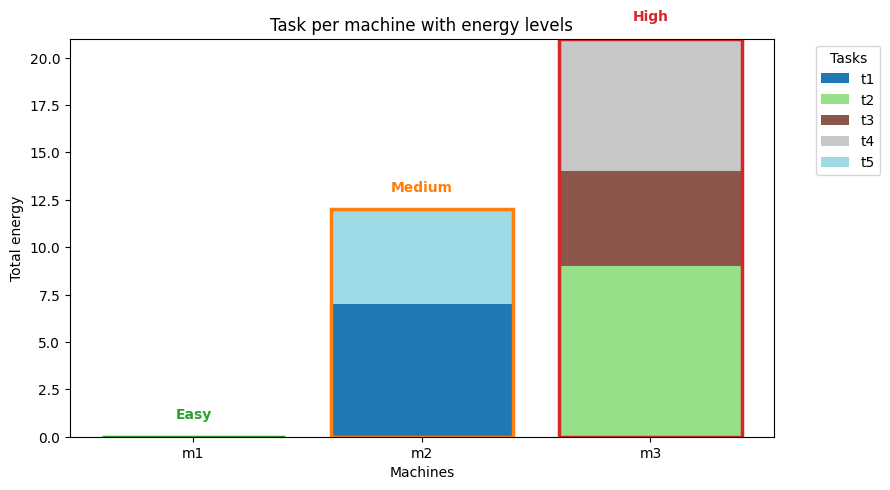

Checking level/energy consistency:
Machine 0 (m1): energy=0, level=0 -> OK
Machine 1 (m2): energy=12, level=1 -> OK
Machine 2 (m3): energy=21, level=2 -> OK


In [86]:
# Tasks
tasks = ["t1", "t2", "t3", "t4", "t5"]
# Machines
machines = ["m1", "m2", "m3"]
# Energy consumption matrix (task, machine)
# energy[task][machine]
energy = {
    "t1": {"m1": 5, "m2": 7, "m3": 5},
    "t2": {"m1": 6, "m2": 5, "m3": 9},
    "t3": {"m1": 5, "m2": 8, "m3": 5},
    "t4": {"m1": 7, "m2": 10, "m3": 7},
    "t5": {"m1": 9, "m2": 5, "m3": 5},
    "t6": {"m1": 7, "m2": 2, "m3": 10},
    "t7": {"m1": 5, "m2": 4, "m3": 10},
    "t8": {"m1": 8, "m2": 8, "m3": 8},
}

# Machine mode thresholds
modes = {
    "Easy":   (0, 10),
    "Medium": (11, 20),
    "High":   (21, float("inf")),
}


model = cp.Model()
nT = len(tasks)
nM = len(machines)
energy_list = [[energy[t][m] for m in machines] for t in tasks]

# x[t,m] = 1 if task t is assigned to machine m
x = cp.boolvar(shape=(nT, nM), name="x")
# total energy for each machine
total_energy = cp.intvar(0, sum(max(energy[t].values()) for t in tasks), shape=nM, name="E")
# intvar representating the energy level for each machine
# 0 for low, 1 for moderate, 2 for high
levels = cp.intvar(0,2,shape=nM, name="energy level")


# each task assigned to exactly one machine
for i in range(nT):
    model.add(sum(x[i, j] for j in range(nM)) == 1)

# compute total energy per machine
for j, m in enumerate(machines):
    model.add(total_energy[j] == sum(energy_list[i][j] * x[i, j] for i in range(nT)))

# ┌────SOLUTION────┐
# implication constraints for the modes
for j in range(nM):
    # easy: energy in [0, easy_max]
    # model += (total_energy[j] <= 10).implies(levels[j] == 0)
    indicator_easy = total_energy[j] <= 10
    M_1 = levels[j].get_bounds()[0] - 0
    M_2 = levels[j].get_bounds()[1] - 0
    model.add((levels[j]) >= M_1*(1 - indicator_easy))
    model.add((levels[j]) <= M_2*(1 - indicator_easy))

    # medium: energy in [easy_max+1, med_max]
    indicator_medium = (total_energy[j] > 10) & (total_energy[j]<=20)
    M_1 = levels[j].get_bounds()[0] - 1
    M_2 = levels[j].get_bounds()[1] - 1
    model.add((levels[j] - 1) >= M_1*(1 - indicator_medium))
    model.add((levels[j] - 1) <= M_2*(1 - indicator_medium))

    # high: energy > med_max
    indicator_high = total_energy[j] > 20
    M_1 = levels[j].get_bounds()[0] - 2
    M_2 = levels[j].get_bounds()[1] - 2
    model.add((levels[j] - 2) >= M_1*(1 - indicator_high))
    model.add((levels[j] - 2) <= M_2*(1 - indicator_high))
# └────────────────┘
model.add(levels[0] == 0)   # machine 0: easy
model.add(levels[1] == 1)   # machine 1: medium
model.add(levels[2] == 2)   # machine 2: high
model.minimize(sum(total_energy))

model.solve()
plot_machine_energy(model,tasks, machines, energy_list, x, total_energy, levels)

### 5.5 Linearization of Global Constraints: AllDifferent

In [87]:
import cpmpy as cp
from cpmpy import SolverLookup

"""
A simple model using the `AllDifferent` global constraint.
"""

# Decision Variables
x = cp.intvar(0, 10, shape=10)

# Model
model = cp.Model()

# Constraints
# 1) all x'es should be different
model.add(cp.AllDifferent(x))

# Solve
solver = SolverLookup().get("gurobi", model)
solver.solve()

# Show result
check_unique_elements(x.value())
print(solver.status())

2 4 1 9 7 5 3 6 0 10 
ExitStatus.FEASIBLE (0.00011086463928222656 seconds)


Going back to the first exercise, create another model with an alternative decomposition for `AllDifferent` that does not use any `!=` but instead a matrix of binary auxiliary variables (as seen in Lecture 07 slide 27).

In [88]:
# Decision Variables
x = cp.intvar(0, 10, shape=10, name='x')
# - auxiliary variables
lb, ub = 0,10 # the bounds of the domain D (see lecture slides on linearization)

"""
TODO: Create matrix B of boolean decision variables.
      B is of shape n x m, where n is the number of variables 'x'
      and m the size of the domain D (the union of all domains of 'x').
      The boolean matrix will act as a one-hot encoding for all the values of 'x'.

      E.g.
        D = [0..3]

        0 = 1 0 0 0
        1 = 0 1 0 0
        2 = 0 0 1 0
        3 = 0 0 0 1

HINT: To determine the size of a domain, calculate the distance between its
      upper- and lower-bound.
"""
# ┌────SOLUTION────┐
B = cp.boolvar(shape=(len(x), 1 + 10 - 0))
# └────────────────┘

# Model
model = cp.Model()

# Constraints
"""
TODO: Complete the constraints for the decomposition,
      exactly as seen in the lecture slides.
"""
# 1) Each variable can get one value (one-hot)
# model += ...
# 2) Each value is assigned to at most one variable (AllDifferent)
# model += ...
# 3) Channeling constraints between 'B' and 'x'
# model += ...

# ┌────SOLUTION────┐
# 1) Each variable can get one value (one-hot)
for i in range(len(x)):
    model.add(cp.sum(B[i, :]) == 1)
# 2) Each value is assigned to at most one variable (AllDifferent)
for j in range(lb, ub+1):
    model.add(cp.sum(B[:, j - lb]) <= 1)
# 3) Channeling constraints between 'B' and 'x'
for a, row in zip(x, B):
    model.add([cp.sum(np.array([i for i in range(lb, ub+1)]) * row) == a])
# └────────────────┘

# Solve
solver = SolverLookup().get("gurobi", model)
solver.solve()

# Show result
check_unique_elements(x.value())
print(solver.status())

2 4 1 9 7 5 3 6 0 10 
ExitStatus.FEASIBLE (0.00011301040649414062 seconds)


#### Big-M constraint bonus exercise

In [91]:
def compute_distances(grid_size=10):
    """
    Computes the Manhattan distance between all pairs of cells in a grid.

    Args:
        grid_size (int): The size of the grid (default is 5).

    Returns:
        dict: A dictionary where the key is a tuple ((i1, j1), (i2, j2)) representing
              two cell coordinates, and the value is the Manhattan distance between them.
    """
    distances = {}
    for i1 in range(grid_size):
        for j1 in range(grid_size):
            for i2 in range(grid_size):
                for j2 in range(grid_size):
                    distance = abs(i1 - i2) + abs(j1 - j2)
                    distances[((i1, j1), (i2, j2))] = distance
    return distances

def check_solution(bought, costs, compactness):
    """
    bought      : 2D boolean array (e.g., 5×5)
    costs       : 2D numeric matrix of same shape
    compactness : CPMpy variable representing compactness
    """

    n = len(costs)            # number of rows
    m = len(costs[0])         # number of columns

    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_facecolor("white")

    # 1) Check compactness
    if compactness.value() != 2:
        print(f"Compactness is {compactness.value()}, expected 2.")

    # 2) Compute total cost
    total_cost = sum(costs[i][j] for i in range(n)
                                    for j in range(m)
                                    if bought[i][j].value())

    if not (200 <= total_cost <= 250):
        print(f"Cost is {total_cost}, expected between 200 and 250.")
    else:
        print(f"Valid solution. Cost = {total_cost}, compactness = 2.")

    # Draw grid
    for i in range(n):
        for j in range(m):

            # Base cell
            rect = patches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                     linewidth=1, edgecolor='black',
                                     facecolor='none')
            ax.add_patch(rect)

            # Cost text
            ax.text(j, i, str(costs[i][j]),
                    ha='center', va='center', fontsize=14)

            # Highlight bought cell
            if bought[i][j].value():
                ax.add_patch(plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1,
                    facecolor="lightgreen",
                    edgecolor="black",
                    linewidth=1.0
                ))

    # No ticks
    ax.set_xticks([])
    ax.set_yticks([])

    # Grid size adapted automatically
    ax.set_xlim(-0.5, m - 0.5)
    ax.set_ylim(n - 0.5, -0.5)

    ax.set_title(f"{n}×{m} Grid With Costs", fontsize=16)

    plt.show()

You want to purchase a set of land plots. The city hall agency provides you a map where each plot is represented as square with an associated cost.
Your goal is to select plots worth more than 200 €, while not exceeding your total budget of 250 €. In addition, you want your plot of lands to be as compact as possible, minimizing the maximum distances of your bought plot of lands.
The map is shown below:

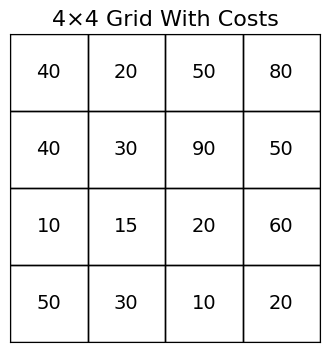

In [92]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define a 4x4 cost matrix
costs = [
    [40, 20, 50, 80],
    [40, 30, 90, 50],
    [10, 15, 20, 60],
    [50, 30, 10, 20]
]

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_facecolor("white")

# Draw grid and place costs
for i in range(4):
    for j in range(4):
        rect = patches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                 linewidth=1, edgecolor='black',
                                 facecolor='none')
        ax.add_patch(rect)
        ax.text(j, i, str(costs[i][j]),
                ha='center', va='center', fontsize=14, color='black')

# No ticks
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-0.5, 3.5)
ax.set_ylim(3.5, -0.5)

ax.set_title("4×4 Grid With Costs", fontsize=16)
plt.show()

The distance between cells is defined using the Manhattan distance:
$d((r, c), (r', c')) = |r - r'| + |c - c'|.$

It can be computed by calling the function `distances = compute_distances()`, where the distance between two cells $(r, c)$ and $(r', c')$ can be accessed with: `distances[(r, c), (r', c')]`.

Model this problem by reducing the compactness definition to a set of **Big-M constraints**. Use [`get_bounds`](https://cpmpy.readthedocs.io/en/latest/api/expressions/variables.html) to help you smartly determine the M value.

**Hint**: In order to represent compactness via an implication, think about this:
If two plots of land are bought, it implies that the compactness must be **at least** their distance.

Valid solution. Cost = 210, compactness = 2.


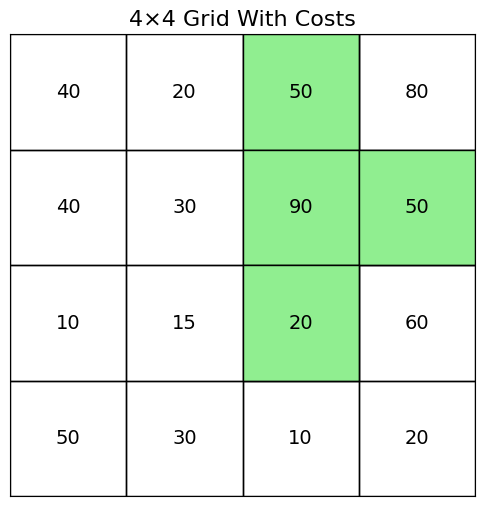

In [93]:
from itertools import combinations

model = cp.Model()
# boolvar indicating if land at index i,j was bought or not
bought = cp.boolvar(shape=(10,10))
#
compactness = cp.intvar(0, 6)
distances = compute_distances(grid_size=4)
# ┌────SOLUTION────┐
# 1) Budget constraint -- we want to spend more than 200 and less than 250
model.add(cp.sum(bought[i,j] * costs[i][j] for i in range(4) for j in range(4)) >= 200)
model.add(-cp.sum(bought[i,j] * costs[i][j] for i in range(4) for j in range(4)) >= -250)
# 2) Definiton of compactness
big_M = compactness.get_bounds()[0] - max(distances.values()) #lb of compactness - distance (min value of compactness is 0, max distance is 6, so min value of compactness - distance is -6)
# - Iteration over all pairs of cells
cells = [(i,j) for i in range(4) for j in range(4)]
for (i1, j1), (i2, j2) in combinations(cells, 2):
    distance = distances[(i1, j1), (i2, j2)]
    # New expression indicating if two cells have been bought
    both_bought = bought[i1, j1] & bought[i2, j2]
    # both_bought.implies(compactness > distance), let's map this to a big-M constraint as seen in slide 23
    model.add(compactness - distance >= big_M * (1 - both_bought))
# └────────────────┘

model.minimize(compactness)
model.solve(solver="gurobi")

check_solution(bought,costs,compactness)